# Short-range electrostatic interaction
## cluster_combined

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as pltx
import matplotlib.pyplot as plt
import glob
%matplotlib inline

In [2]:
#cutoff for electrostat contact
contact_dist = 4
#making empty lists to put contact files in
nosalt_binding_sims = []
salt_binding_sims = []

In [3]:
#loading in all electrostat files from ArkA12 binding and binding with salt sims
nosalt_binding_sims = glob.glob('/data/rcarrock/ArkA_binding_cont/analysis_all/electrostat/*.dat')
salt_binding_sims = glob.glob('/data/mcohen3/SH3/analysis/electrostat/dat/*.dat')

#loading in status file so can define unbound, bound, and encounter within the ArkA12 binding sims
ArkA12_status = pd.read_csv("/data/rcarrock/ArkA_binding_cont/analysis_all/ArkA12_status.csv")
ArkA12_status_salt = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')

# Binding simulations

# ArkA12 binding simulations

In [4]:
#define number of independent sims for bound sims
num_binding_sims = 50
#make dataframes for the fraction of electrostats and for the sem of that
electrostat_frac = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'])
electrostat_frac_sem = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'])
#make dataframe for total electrostat frac for each independent bound sim 
total_electrostat_frac_binding = pd.DataFrame(0, columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'], index = range(0,num_binding_sims))

for file_name in nosalt_binding_sims:
    df_binding = pd.read_table(file_name, sep = '\s+')
    df_binding = df_binding.drop(['#Frame'], axis=1)
    df_binding.columns = ['fraction']
    df_binding['status'] = ArkA12_status['status']
    
#calculate the mean for each contact over all independent sims
    #less than contact_dist
    less_than_10 = df_binding['fraction'] < contact_dist 
    electrostat_frac.loc[file_name.split('/')[-1],
                     'binding nosalt'] = np.mean(less_than_10)
    
    #less than contact_dist and unbound
    less_than_10_unbound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'unbound'))
    len_sim_unbound = (df_binding['status'] == 'unbound').sum()
    num_contacts_unbound = less_than_10_unbound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'unbound nosalt'] = (num_contacts_unbound/len_sim_unbound)
    
    #less than contact_dist and encounter
    less_than_10_encounter = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound'))
    len_sim_encounter = ((df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound')).sum()
    num_contacts_encounter = less_than_10_encounter.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'encounter nosalt'] = (num_contacts_encounter/len_sim_encounter)
    
     #less than contact_dist and bound
    less_than_10_bound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'Bound'))
    len_sim_bound = (df_binding['status'] == 'Bound').sum()
    num_contacts_bound = less_than_10_bound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'bound nosalt'] = (num_contacts_bound/len_sim_bound)

#calculate standard error of the mean
    num_binding_snapshots = int(len(df_binding)/num_binding_sims)

    frac_by_sim = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt'])
    
    #go through each of the independent binding simulations
    for sim in range(0,num_binding_sims):
        #less than contact_dist
        frac_by_sim.loc[sim,'binding nosalt'] = np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)
        total_electrostat_frac_binding.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)

        #less than contact_dist and unbound
        df_sim = df_binding[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots] 
        less_than_10_unbound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'unbound'))
        len_sim_unbound_sim = (df_sim['status'] == 'unbound').sum()
        num_contacts_unbound_sim = less_than_10_unbound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'unbound nosalt'] = (num_contacts_unbound_sim/len_sim_unbound_sim)
        total_electrostat_frac_binding.loc[sim,'unbound nosalt'] += (num_contacts_unbound_sim/len_sim_unbound_sim)
        
        #less than contact_dist and encounter 
        less_than_10_encounter_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound'))
        len_sim_encounter_sim = ((df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound')).sum()
        num_contacts_encounter_sim = less_than_10_encounter_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'encounter nosalt'] = (num_contacts_encounter_sim/len_sim_encounter_sim)
        total_electrostat_frac_binding.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
        
        #less than contact_dist and bound 
        less_than_10_bound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'Bound'))
        len_sim_bound_sim = (df_sim['status'] == 'Bound').sum()
        num_contacts_bound_sim = less_than_10_bound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'bound nosalt'] = (num_contacts_bound_sim/len_sim_bound_sim)
        total_electrostat_frac_binding.loc[sim,'bound nosalt'] += (num_contacts_bound_sim/len_sim_bound_sim)
        
    electrostat_frac_sem.loc[file_name.split('/')[-1],'binding nosalt'] = frac_by_sim.sem()['binding nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'unbound nosalt'] = frac_by_sim.sem()['unbound nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'encounter nosalt'] = frac_by_sim.sem()['encounter nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'bound nosalt'] = frac_by_sim.sem()['bound nosalt']
electrostat_frac

/tmp/ipykernel_3131650/1808566191.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.05264' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
/tmp/ipykernel_3131650/1808566191.py:75: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.03687668282175552' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
/tmp/ipykernel_3131650/1808566191.py:83: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2573426573426573' has dtype incompatible with int64, please e

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.105209,0.017583,0.544999,0.028593,NaN,NaN,NaN,NaN
D11_K60.dat,0.052577,0.013094,0.054251,0.052285,NaN,NaN,NaN,NaN
D15_K60.dat,0.005657,0.024141,0.0,0.006643,NaN,NaN,NaN,NaN
D24_K60.dat,0.001577,0.008118,0.0,0.001851,NaN,NaN,NaN,NaN
D33_K60.dat,0.020296,0.00798,0.0,0.023832,NaN,NaN,NaN,NaN
D34_K60.dat,0.005349,0.005756,0.0,0.00628,NaN,NaN,NaN,NaN
D35_K60.dat,0.023687,0.008722,0.000001,0.027813,NaN,NaN,NaN,NaN
D44_K60.dat,0.001311,0.008161,0.0,0.001539,NaN,NaN,NaN,NaN
E7_K60.dat,0.044559,0.008628,0.027521,0.047527,NaN,NaN,NaN,NaN
E14_K60.dat,0.024965,0.00798,0.0,0.029315,NaN,NaN,NaN,NaN


In [5]:
electrostat_frac_sem

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.027617,0.009561,0.056779,0.010209,NaN,NaN,NaN,NaN
D11_K60.dat,0.013091,0.004333,0.031796,0.013864,NaN,NaN,NaN,NaN
D15_K60.dat,0.001526,0.0093,0.0,0.002388,NaN,NaN,NaN,NaN
D24_K60.dat,0.00109,0.003338,0.0,0.00109,NaN,NaN,NaN,NaN
D33_K60.dat,0.008424,0.001669,0.0,0.008423,NaN,NaN,NaN,NaN
D34_K60.dat,0.001177,0.001935,0.0,0.001214,NaN,NaN,NaN,NaN
D35_K60.dat,0.007019,0.001527,0.000047,0.007074,NaN,NaN,NaN,NaN
D44_K60.dat,0.000549,0.001851,0.0,0.000824,NaN,NaN,NaN,NaN
E7_K60.dat,0.009687,0.00324,0.028405,0.009719,NaN,NaN,NaN,NaN
E14_K60.dat,0.009765,0.003756,0.0,0.009752,NaN,NaN,NaN,NaN


In [6]:
electrostat_frac
electrostat_frac["binding nosalt"].mean()

0.030370897777777777

In [7]:
electrostat_frac
electrostat_frac["binding nosalt"].sem()

0.005644455675974908

In [8]:
electrostat_frac
electrostat_frac["unbound nosalt"].mean()

0.008794878557985043

In [9]:
electrostat_frac
electrostat_frac["bound nosalt"].mean()

0.046956447499971916

In [10]:
electrostat_frac
electrostat_frac["bound nosalt"].sem()

0.021516280527468394

In [11]:
electrostat_frac
electrostat_frac["encounter nosalt"].mean()

0.027481496702747583

In [12]:
electrostat_frac
electrostat_frac["encounter nosalt"].sem()

0.004524033800452936

# Binding with salt 

In [13]:
#define number of independent sims for binding sims
num_binding_sims = 50
#make dataframe for total electrostat frac for each independent binding sim
total_electrostat_frac_binding_salt = pd.DataFrame(0, columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'], index = range(0,num_binding_sims))

for file_name in salt_binding_sims:
    df_binding = pd.read_table(file_name, sep = '\s+')
    df_binding = df_binding.drop(['#Frame'], axis=1)
    df_binding.columns = ['fraction']
    df_binding['status'] = ArkA12_status_salt['status']
    
#calculate the mean for each contact over all independent sims
    #less than contact_dist
    less_than_10 = df_binding['fraction'] < contact_dist 
    electrostat_frac.loc[file_name.split('/')[-1],
                     'binding 800 NaCl'] = np.mean(less_than_10)
    
    #less than contact_dist and unbound
    less_than_10_unbound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'unbound'))
    len_sim_unbound = (df_binding['status'] == 'unbound').sum()
    num_contacts_unbound = less_than_10_unbound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'unbound 800 NaCl'] = (num_contacts_unbound/len_sim_unbound)
    
    #less than contact_dist and encounter
    less_than_10_encounter = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound'))
    len_sim_encounter = ((df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound')).sum()
    num_contacts_encounter = less_than_10_encounter.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'encounter 800 NaCl'] = (num_contacts_encounter/len_sim_encounter)
    
     #less than contact_dist and bound
    less_than_10_bound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'Bound'))
    len_sim_bound = (df_binding['status'] == 'Bound').sum()
    num_contacts_bound = less_than_10_bound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'bound 800 NaCl'] = (num_contacts_bound/len_sim_bound)

#calculate standard deviation
    num_binding_snapshots = int(len(df_binding)/num_binding_sims)

    frac_by_sim = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt'])
    
    #go through each of the independent binding simulations
    for sim in range(0,num_binding_sims):
        #less than contact_dist
        frac_by_sim.loc[sim,'binding nosalt'] = np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)
        total_electrostat_frac_binding_salt.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)

        #less than contact_dist and unbound
        df_sim = df_binding[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots] 
        less_than_10_unbound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'unbound'))
        len_sim_unbound_sim = (df_sim['status'] == 'unbound').sum()
        num_contacts_unbound_sim = less_than_10_unbound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'unbound nosalt'] = (num_contacts_unbound_sim/len_sim_unbound_sim)
        total_electrostat_frac_binding_salt.loc[sim,'unbound nosalt'] += (num_contacts_unbound_sim/len_sim_unbound_sim)
        
        #less than contact_dist and encounter 
        less_than_10_encounter_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound'))
        len_sim_encounter_sim = ((df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound')).sum()
        num_contacts_encounter_sim = less_than_10_encounter_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'encounter nosalt'] = (num_contacts_encounter_sim/len_sim_encounter_sim)
        total_electrostat_frac_binding_salt.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
        
        #less than contact_dist and bound 
        less_than_10_bound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'Bound'))
        len_sim_bound_sim = (df_sim['status'] == 'Bound').sum()
        num_contacts_bound_sim = less_than_10_bound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'bound nosalt'] = (num_contacts_bound_sim/len_sim_bound_sim)
        total_electrostat_frac_binding_salt.loc[sim,'bound nosalt'] += (num_contacts_bound_sim/len_sim_bound_sim)
        
    electrostat_frac_sem.loc[file_name.split('/')[-1],'binding 800 NaCl'] = frac_by_sim.sem()['binding nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'unbound 800 NaCl'] = frac_by_sim.sem()['unbound nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'encounter 800 NaCl'] = frac_by_sim.sem()['encounter nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'bound 800 NaCl'] = frac_by_sim.sem()['bound nosalt']
electrostat_frac

/tmp/ipykernel_3131650/17285590.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.13945' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding_salt.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
/tmp/ipykernel_3131650/17285590.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.01339328059491966' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding_salt.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
/tmp/ipykernel_3131650/17285590.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2799712394527037' has dtype incompatible with int64, plea

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.105209,0.017583,0.544999,0.028593,0.050976,0.001302,0.385751,0.008768
D11_K60.dat,0.052577,0.013094,0.054251,0.052285,0.010748,0.000632,0.049613,0.005848
D15_K60.dat,0.005657,0.024141,0.0,0.006643,0.00164,0.002465,0.0,0.001847
D24_K60.dat,0.001577,0.008118,0.0,0.001851,0.000145,0.000574,0.0,0.000163
D33_K60.dat,0.020296,0.00798,0.0,0.023832,0.00718,0.002545,0.0,0.008086
D34_K60.dat,0.005349,0.005756,0.0,0.00628,0.001611,0.00131,0.0,0.001814
D35_K60.dat,0.023687,0.008722,0.000001,0.027813,0.014411,0.00332,0.0,0.016228
D44_K60.dat,0.001311,0.008161,0.0,0.001539,0.000306,0.0006,0.0,0.000345
E7_K60.dat,0.044559,0.008628,0.027521,0.047527,0.005408,0.000959,0.003087,0.005701
E14_K60.dat,0.024965,0.00798,0.0,0.029315,0.024365,0.002433,0.0,0.027437


In [14]:
electrostat_frac
electrostat_frac["binding 800 NaCl"].mean()

0.015643582222222223

In [15]:
electrostat_frac
electrostat_frac["binding 800 NaCl"].sem()

0.005047817331032054

In [16]:
electrostat_frac
electrostat_frac["unbound 800 NaCl"].mean()

0.0019030588616477456

In [17]:
electrostat_frac
electrostat_frac["bound 800 NaCl"].mean()

0.037232498434502666

In [18]:
electrostat_frac
electrostat_frac["bound 800 NaCl"].sem()

0.02045142923070773

In [19]:
electrostat_frac
electrostat_frac["encounter 800 NaCl"].mean()

0.01292166880434036

In [20]:
electrostat_frac
electrostat_frac["encounter 800 NaCl"].sem()

0.00490045358124013

In [21]:
#calcs amount of contacts occuring on average at any given time
(electrostat_frac.mean())*len(electrostat_frac)

binding nosalt         1.36669
unbound nosalt         0.39577
bound nosalt           2.11304
encounter nosalt      1.236667
binding 800 NaCl      0.703961
unbound 800 NaCl      0.085638
bound 800 NaCl        1.675462
encounter 800 NaCl    0.581475
dtype: object

In [22]:
#calcs amount of contacts occuring on average at any given time
(electrostat_frac.sem())*len(electrostat_frac)

binding nosalt        0.254001
unbound nosalt        0.049013
bound nosalt          0.968233
encounter nosalt      0.203582
binding 800 NaCl      0.227152
unbound 800 NaCl       0.01511
bound 800 NaCl        0.920314
encounter 800 NaCl     0.22052
dtype: object

In [23]:
# ArkA12 binding_salt effect of NaCl (JUST SHORT)
ArkA12_avg_hb_values = np.concatenate([(electrostat_frac["encounter nosalt"]*len(electrostat_frac)),
                                           (electrostat_frac["encounter 800 NaCl"]*len(electrostat_frac))])
#calculate the real difference, no salt minus salt
diff_ArkA12_short = ((electrostat_frac["encounter nosalt"].mean()*len(electrostat_frac)))\
        - ((electrostat_frac["encounter 800 NaCl"].mean()*len(electrostat_frac)))\

print("ArkA12 binding_salt 800 mM NaCl vs no-salt difference = " , diff_ArkA12_short)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_binding_sims]) 
             - np.mean(random_groups[num_binding_sims:num_binding_sims 
                                                + num_binding_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_short:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA12 binding_salt 800 mM NaCl vs no-salt difference =  0.655192255428325
p-value =  0.0084991500849915


In [24]:
electrostat_frac.to_csv('ArkA12_EC_short_range_EI_fracs.csv', columns=['encounter nosalt','encounter 800 NaCl'],index=False)

In [25]:
#cutoff for important contacts b/c don't need ones w/o important role 
frac_cutoff = 0.1 
common_contacts = electrostat_frac > frac_cutoff

In [26]:
#making it so only those that meet cutoff show
electrostat_frac['important'] = common_contacts.any(axis = 1)
electrostat_frac_subset = electrostat_frac[electrostat_frac['important']]

#ditto but for sem
electrostat_frac_sem['important'] = common_contacts.any(axis = 1)
electrostat_frac_sem_subset = electrostat_frac_sem[electrostat_frac_sem['important']]

In [27]:
#checking new length... went from 45 to 25 contacts
len(electrostat_frac_sem_subset)

6

In [28]:
# total_electrostat_frac_binding

In [29]:
electrostat_frac_subset

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
D9_K60.dat,0.105209,0.017583,0.544999,0.028593,0.050976,0.001302,0.385751,0.008768,True
E17_K60.dat,0.091013,0.023765,0.000093,0.106853,0.196572,0.01474,0.000016,0.221354,True
E22_K60.dat,0.136058,0.006954,0.072601,0.147113,0.01944,0.001093,0.009614,0.020679,True
E14_K66.dat,0.08468,0.013286,0.407428,0.028454,0.037414,0.001209,0.251338,0.010443,True
E17_K66.dat,0.174217,0.001992,0.719339,0.07925,0.120594,0.000055,0.815925,0.032927,True
E14_K71.dat,0.046138,0.012059,0.124035,0.032567,0.014858,0.001648,0.082538,0.006325,True


In [30]:
len(electrostat_frac[electrostat_frac['important']])

6

In [31]:
electrostat_frac[electrostat_frac['important']]

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
D9_K60.dat,0.105209,0.017583,0.544999,0.028593,0.050976,0.001302,0.385751,0.008768,True
E17_K60.dat,0.091013,0.023765,0.000093,0.106853,0.196572,0.01474,0.000016,0.221354,True
E22_K60.dat,0.136058,0.006954,0.072601,0.147113,0.01944,0.001093,0.009614,0.020679,True
E14_K66.dat,0.08468,0.013286,0.407428,0.028454,0.037414,0.001209,0.251338,0.010443,True
E17_K66.dat,0.174217,0.001992,0.719339,0.07925,0.120594,0.000055,0.815925,0.032927,True
E14_K71.dat,0.046138,0.012059,0.124035,0.032567,0.014858,0.001648,0.082538,0.006325,True


In [32]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_subset_rn = electrostat_frac_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_subset_rn = electrostat_frac_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_subset_rn

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
K(3) to D9,0.105209,0.017583,0.544999,0.028593,0.050976,0.001302,0.385751,0.008768,True
K(3) to D11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E17,0.091013,0.023765,0.000093,0.106853,0.196572,0.01474,0.000016,0.221354,True
K(3) to E22,0.136058,0.006954,0.072601,0.147113,0.01944,0.001093,0.009614,0.020679,True
K(-3) to D9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
len(electrostat_frac_subset)

6

In [34]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_sem_subset_rn

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
K(3) to D9,0.027617,0.009561,0.056779,0.010209,0.014939,0.000574,0.053527,0.004937,True
K(3) to D11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(3) to E17,0.027056,0.007418,0.014827,0.02711,0.042295,0.015351,0.001181,0.042397,True
K(3) to E22,0.033958,0.006628,0.06131,0.033722,0.010393,0.000492,0.078052,0.010137,True
K(-3) to D9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K(-3) to D33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# len(electrostat_frac[electrostat_frac['important']])
len(electrostat_frac_sem_subset)

6

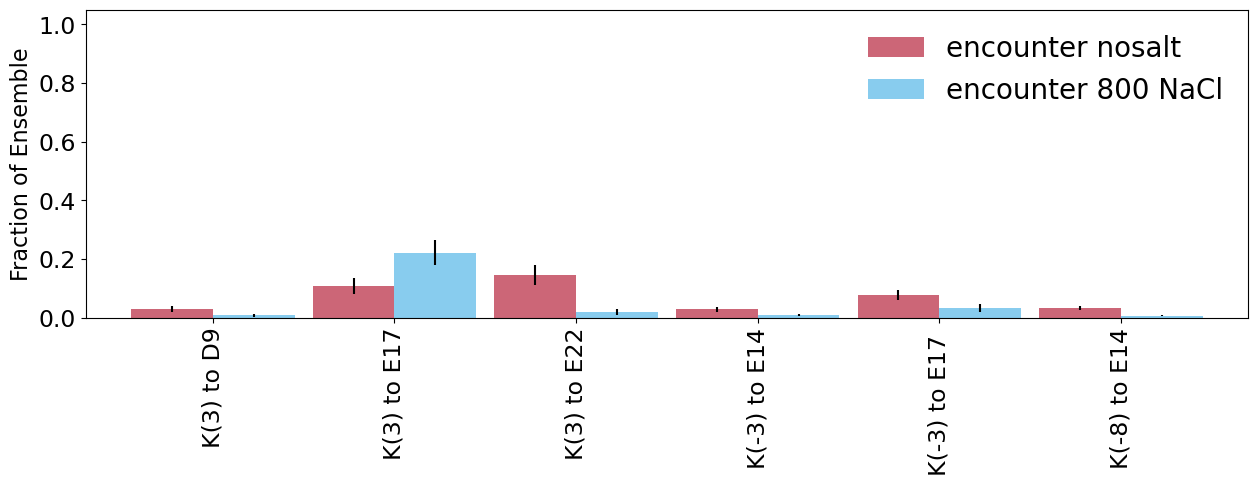

In [36]:
#making plot
plt.rcParams['figure.figsize'] = [15, 4]
ax1 = electrostat_frac_subset_rn.dropna(axis=0)[['encounter nosalt', 'encounter 800 NaCl']].plot.bar(fontsize = 17, width=0.9,color=['#CC6677','#88CCEE'], 
 yerr = electrostat_frac_sem_subset_rn.dropna(axis=0)[['encounter nosalt', 'encounter 800 NaCl']])

ax1.set_ylim(bottom=0, top=1.05)
plt.ylabel('Fraction of Ensemble', size =16) # gives a name to the y-axis
plt.legend(fontsize = 20, frameon=False, loc="upper right")
plt.savefig('electrostats_bound_encounter_short_ArkA12_with_errbars.png', dpi=2000)